Nombre y apellidos: Alfonso Íñiguez Cortés \
Correo: aic35@alu.ua.es \
Grupo: 3 

# BFS. Exploración de grafos

In [11]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown 

Implementación del algoritmo BFS:

In [ ]:
def bfs_numpy(graph, source, target):
    nodes = list(graph.nodes())
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    visited = np.zeros(len(nodes), dtype=bool)
    source_index = nodes.index(source)
    target_index = nodes.index(target)
    visited[source_index] = True

    to_explore = [source_index]
    current_position = 0  

    parent = np.ones(len(nodes), dtype=int) * -1
    steps = 0

    while current_position < len(to_explore):
        steps += 1
        current_index = to_explore[current_position]
        current_position += 1

        if current_index == target_index:
            break

        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                parent[neighbor_index] = current_index

    shortest_path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            shortest_path.insert(0, nodes[current])
            current = parent[current]

    return steps, shortest_path

## Ejercicios

### Ejercicio 1

El algoritmo BFS es un algoritmo de exploración de grafos. Este algoritmo explora el grafo por niveles: visita a un vecino, luego a los vecinos del vecino y asi sucesivamente. De esa forma, después de explorar un grafo al completo el algoritmo sabe siempre cual es el camino más corto de un nodo hasta otro, es decir, este algoritmo garantiza siempre el **camino más óptimo** (entre un _target_ (destino) y un _source_ (origen))

### Explicación algoritmo

- #### Bloque 1 - Inicialización
---

In [ ]:
nodes = list(graph.nodes())
adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

visited = np.zeros(len(nodes), dtype=bool)
source_index = nodes.index(source)
target_index = nodes.index(target)
visited[source_index] = True

to_explore = [source_index]
current_position = 0  

parent = np.ones(len(nodes), dtype=int) * -1
steps = 0

- **nodes** &rarr; Lista ordenada de todos los nodos del grafo. La lista es necesaria puesto que se trabaja con los índices de los nodos, no con los nombres reales de estos.

- **adjacency_matrix** &rarr; Matriz NxN donde la celda ```[i][j] = 1``` si hay una arsita entre el nodo i y el nodo j. Si no hay arista, el valor correspondiente es 0.

- **visited** &rarr; Array de valores booleanos, uno por nodo. Este array nos dice que nodo ya ha sido explorado, lo cual sirve para no explorar el mismo nodo más de una vez (podría casar bucles)

- **source_index** &rarr; Índice del nodo donde comienza la búsqueda

- **target_index** &rarr; Índice del nodo que queremos alcanzar 

- **visited[source_index]** &rarr; Marcamos como visitado el nodo desde el cual comenzamos la búsqueda

- **to_explore** &rarr; Cola pendiente del BFS, es decir, los nodos pendientes de explorar. Esta lista comienza en el nodo de origen

- **current_position** &rarr; PUntero que avanza. Apunta al siguiente nodo a explorar

- **parent** &rarr; Array que guarda, por cada nodo, desde qué nodo hemos llegado hasta a él. Este array es el que se usa para reconstruir el camino final. El array esta inicializado a -1 (todos) ya que ningún nodo tiene padre todavía

- **steps** &rarr; Contador de iteraciones del bucle principal

- #### Bucle principal
---

In [ ]:
while current_position < len(to_explore):
    steps += 1
    current_index = to_explore[current_position]
    current_position += 1

    if current_index == target_index:
        break

    neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
    for neighbor_index in neighbors:
        if not visited[neighbor_index]:
            visited[neighbor_index] = True
            to_explore.append(neighbor_index)
            parent[neighbor_index] = current_index

- _while_ &rarr; El bucle continúa hasta que queden nodos por explorar. Lo que hacemos es seleccionar al nodo que apunta a **current_position** y avanzamos el puntero. Imita el comportamiento *FIFO (First In First Out)* de una cola. De esta forma se garantiza que este algoritmo explore el grafo por niveles

- **current_index** &rarr; Seleccionamos al nodo que apunta a **current_position**

- **current_position** &rarr; Avanzamos el puntero para la siguiente iteración. Esta estructura imita el comportamiento *FIFO (First In First Out)* de una cola. De esta forma se garantiza que este algoritmo explore el grafo por niveles

- **steps** &rarr; Sumamos uno por iteración

- _if_ &rarr; Si el nodo actual es igual que el nodo destino, hemos encontrado el camino más corto y el bucle finaliza. Podemos para aquí ya que BFS garantiza que el primero en llegar al destino llegó por el camino más corto

- **neighbors** &rarr; Mira la fila del nodo actual en la matriz de adyacencia y devuelve los índices donde haya un uno, es decir, donde exista una arsita, es decir, sus vecinos

- _for_ &rarr; Bucle donde se recorren los vecinos del nodo actual. Para cada vecino: si no ha sido visitado, se marca como visitado, lo añadimos a la cola con los nodos a explorar y guardamos que hemos llegado hasta el desde el nodo actual (para la reconstrucción)


- #### Bloque 3 - Reconstrucción del camino
---

In [ ]:
shortest_path = []
if parent[target_index] != -1 or source_index == target_index:
    current = target_index
    while current != -1:
        shortest_path.insert(0, nodes[current])
        current = parent[current]

return steps, shortest_path

- **shortest_path** &rarr; Lista donde se van a guardar los índices del camino más corto entre el _source_ y el _target_

- _if_ &rarr; Si el nodo final no tiene padres o el nodo inicial y el final son el mismo nodo no se puede realizar la reconstrucción

- **current** &rarr; Comenzamos la reconstrucción desde atrás, luego asignamos el nodo destino al nodo actual

- _while_ &rarr; El único nodo sin padre (valor -> -1) es el nodo origen. Este bucle recorre los nodos hasta llegar al padre (justo antes de procesarlo)

- **shortest_path.insert** &rarr; Insertamos el nodo actual al principio de la lista. Lo hacemos así puesto que recorremos el camino hacia atrás (obtendríamos el camino pero al revés)

- **current = parent[current]** &rarr; Seleccionamos el padre del nodo actual para seguir reconstruyendo el camino

#### BFS con prints

In [26]:
def bfs_numpy(graph, source, target):
    """"
    Función que implementa el algoritmo BFS. Se usan prints para que se muestre
    que pasos esta siguiendo el algoritmo.

    Args
    -------
        - graph: Grafo que se va a explorar
        - source: Nodo del que se comienza la exploración
        - target: Nodo que se quiere encontrar

    Returns
    --------
        - steps: Número de pasos que usa BFS para encontrar el camino
        - shortest_path: Camino más corto entre source y target
    
    """

    display(Markdown(f'## Analizando el grafo con BFS \n---'))
    nodes = list(graph.nodes())
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    visited = np.zeros(len(nodes), dtype=bool)
    source_index = nodes.index(source)
    target_index = nodes.index(target)
    visited[source_index] = True

    to_explore = [source_index]
    current_position = 0  

    parent = np.ones(len(nodes), dtype=int) * -1
    steps = 0

    # Inicialización
    display(Markdown(f'### <u>Datos iniciales</u>'))
    print(f'Nodos: {nodes}')
    print(f'Nodo inicial: {nodes[source_index]}')
    print(f'Nodo a buscar: {nodes[target_index]}')

    display(Markdown(f'_iniciando búsqueda..._'))

    while current_position < len(to_explore):
        steps += 1
        current_index = to_explore[current_position]
        current_position += 1

        if current_index == target_index:
            print(f'Nodo final encontrado')
            break

        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                parent[neighbor_index] = current_index

    shortest_path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            shortest_path.insert(0, nodes[current])
            current = parent[current]

    display(Markdown(f'### Resultados obtenidos\n---'))
    print(f'Número de pasos: {steps}')
    print(f'Camino más óptimo: {shortest_path}')
    print(f'Longitud del camino; {len(shortest_path) - 1} aristas')

    return steps, shortest_path

## Grafos sintéticos

#### **ERDOS-RENYI**

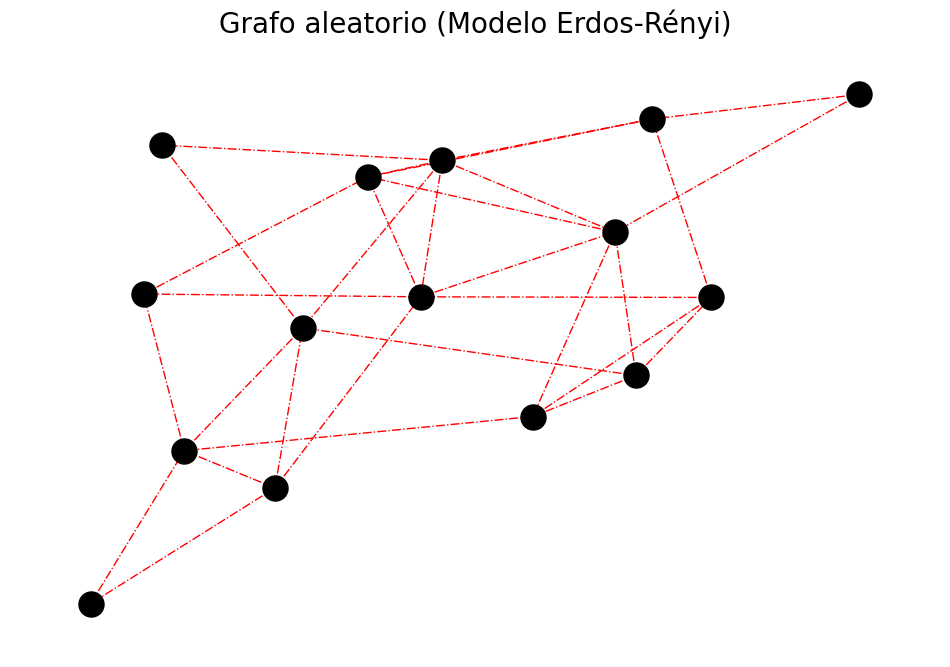

---

## Analizando el grafo con BFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 4
Nodo a buscar: 7


_iniciando búsqueda..._

Nodo final encontrado


### Resultados obtenidos
---

Número de pasos: 11
Camino más óptimo: [4, 1, 7]
Longitud del camino; 2 aristas


(11, [4, 1, 7])

In [ ]:
######################################
# ERDOS-RENYI
######################################

e_r = nx.erdos_renyi_graph(15, 0.25)   # 15 nodos | Probabilidad de arista del 25%

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Erdos-Rényi)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(e_r, seed = 18)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(e_r, posiciones, node_color = 'black', node_size = 325)
nx.draw_networkx_edges(e_r, posiciones, edge_color = 'red', style = '-.')

plt.axis('off')
plt.show()
display(Markdown("---"))

# EJECUTAMOS EL AGORITMO
bfs_numpy(e_r, 4, 7)

---

#### **BARABASI-ALBERT**

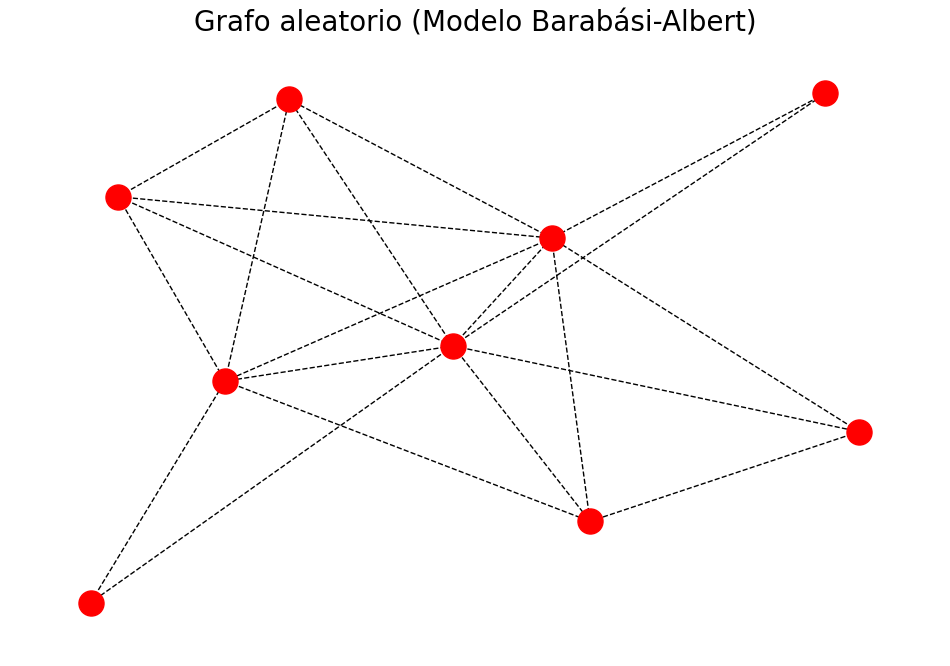

---

## Analizando el grafo con BFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 4
Nodo a buscar: 8


_iniciando búsqueda..._

Nodo final encontrado


### Resultados obtenidos
---

Número de pasos: 9
Camino más óptimo: [4, 0, 8]
Longitud del camino; 2 aristas


(9, [4, 0, 8])

In [28]:
######################################
# BARABASI-ALBERT
######################################

b_a = nx.barabasi_albert_graph(9, 4, seed=10)   # 10 nodos | Nº enlaces por nodo

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Barabási-Albert)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(b_a, seed = 8)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(b_a, posiciones, node_color = 'red', node_size = 325)
nx.draw_networkx_edges(b_a, posiciones, edge_color = 'black', style = '--')

plt.axis('off')
plt.show()
display(Markdown("---"))

# CALCULAMOS EL ALGORITMO
bfs_numpy(b_a, 4,8)

---

#### **WATTS-STROGATZ**

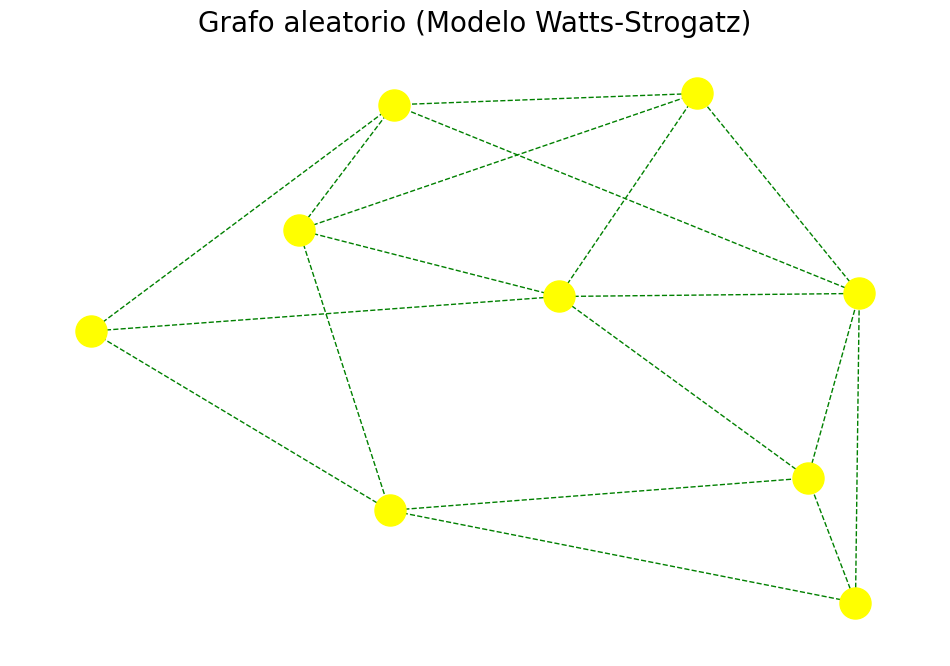

---

## Analizando el grafo con BFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 6
Nodo a buscar: 8


_iniciando búsqueda..._

Nodo final encontrado


### Resultados obtenidos
---

Número de pasos: 6
Camino más óptimo: [6, 8]
Longitud del camino; 1 aristas


(6, [6, 8])

In [31]:
######################################
# WATTS-STROGATZ
######################################

w_s = nx.watts_strogatz_graph(9, 4, 0.5)   # 9 nodos | Grado medio | Probabilidad reconexión

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Watts-Strogatz)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(w_s, seed = 16)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(w_s, posiciones, node_color = 'yellow', node_size = 500)
nx.draw_networkx_edges(w_s, posiciones, edge_color = 'green', style = '--')

plt.axis('off')
plt.show()
display(Markdown("---"))

# EJECUTAMOS EL ALGORTIMO
bfs_numpy(w_s, 6, 8)

#### **GRAFOS EN ÁRBOL**

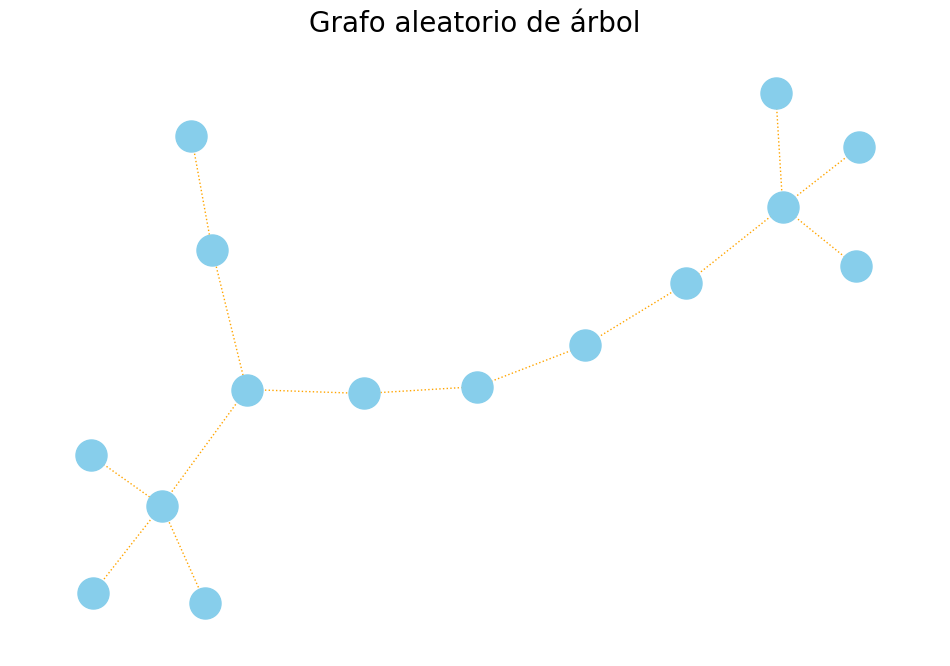

---

## Analizando el grafo con BFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 2
Nodo a buscar: 7


_iniciando búsqueda..._

Nodo final encontrado


### Resultados obtenidos
---

Número de pasos: 5
Camino más óptimo: [2, 3, 7]
Longitud del camino; 2 aristas


(5, [2, 3, 7])

In [32]:
######################################
# TREE
######################################

# Usamos la función "random_tree" para generar un grafo de árbol
t = nx.random_tree(15, seed=99)   # 15 nodos

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio de árbol', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(t, seed = 16)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(t, posiciones, node_color = 'skyblue', node_size = 500)
nx.draw_networkx_edges(t, posiciones, edge_color = 'orange', style = ':')

plt.axis('off')
plt.show()
display(Markdown("---"))

# EJECUTAMOS EL ALGORITMO
bfs_numpy(t, 2, 7)

#### **STOCHASTIC BLOCK MODEL**

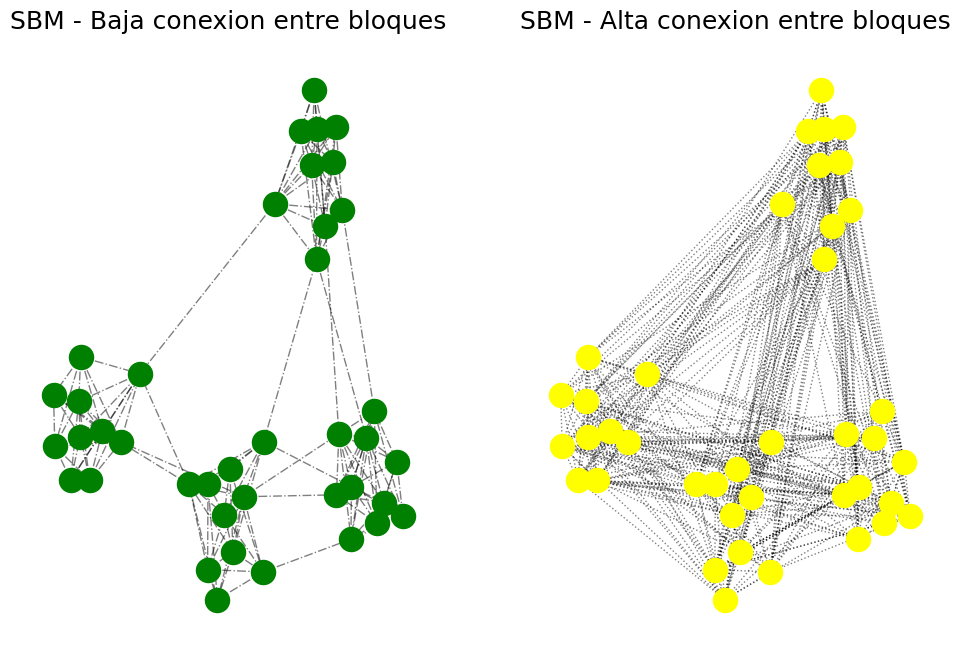

## Analizando el grafo con BFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 30, 31]
Nodo inicial: 6
Nodo a buscar: 13


_iniciando búsqueda..._

Nodo final encontrado


...

_iniciando búsqueda..._

Nodo final encontrado


### Resultados obtenidos
---

Número de pasos: 33
Camino más óptimo: [6, 1, 13]
Longitud del camino; 2 aristas


(33, [6, 1, 13])

In [36]:
######################################
# STOCHASTIC_BLOCK_MODEL (SBM)
######################################
# Creamos 4 bloques de 10 nodos cada uno
sizes = [10, 10, 10, 10]

# Definimos las matrices de probabilidad:
    # Baja: Probabilidad baja conexión entre bloques distintos
    # Alta: Probabilidad alta conexión entre bloques distintos
baja = [
    [0.8, 0.02, 0.02, 0.02],
    [0.02, 0.8, 0.02, 0.02],
    [0.02, 0.02, 0.8, 0.02],
    [0.02, 0.02, 0.02, 0.8]
]
alta = [
    [0.8, 0.4, 0.4, 0.4],
    [0.4, 0.8, 0.4, 0.4],
    [0.4, 0.4, 0.8, 0.4],
    [0.4, 0.4, 0.4, 0.8]
]
# Definimos la semilla para que los resultados sean reproducibles
seed = 96

# Creamos los 2 grafos (SBM)
G1 = nx.stochastic_block_model(sizes, baja, seed=seed)  # El primero -> Probabilidad alta
G2 = nx.stochastic_block_model(sizes, alta, seed=seed)  # El segundo -> Probabilidad baja

# Calculamos las posiciones (las mismas para los dos grafos)
pos = nx.spring_layout(G1, seed=seed)
# Vamos a dividir los dos grafos en una misma figura
fig, axes = plt.subplots(1, 2, figsize=(12,8))

# Primer grafo
#--------------#
# Definimos título
axes[0].set_title('SBM - Baja conexion entre bloques', fontsize = 18)  
nx.draw_networkx_nodes(G1, pos, node_size=300, node_color='green', ax=axes[0])  # Dibujamos los nodos
nx.draw_networkx_edges(G1, pos, width=1.0, alpha=0.5, edge_color='black', style='-.', ax=axes[0]) # Dibujamos las aristas
axes[0].axis('off')

# Segundo grafo
#---------------#
# Definimos título
axes[1].set_title('SBM - Alta conexion entre bloques', fontsize = 18)
nx.draw_networkx_nodes(G2, pos, node_size=300, node_color= 'yellow', ax=axes[1])         # Dibujamos los nodos
nx.draw_networkx_edges(G2, pos, width=1.0, alpha=0.5, style=':', ax=axes[1])  # Dibujamos las arsitas
axes[1].axis('off')

# Mostramos el resultado por pantalla
plt.show()


# EJECUTAMOS EL ALGORITMO
bfs_numpy(G1, 6, 13)
display(Markdown(f'---'))
display(Markdown(f'---'))
bfs_numpy(G2, 6, 13)

Ahora que ya tenemos los gafros sintéticos creados, vamos a ver como BFS recorre estos algoritmos:

# Ejercicio 2

Vamos a aplicar el algoritmo a los grafos sintéticos creados anteriormente mostrando un ejemplo donde los nodos destino y origen están cerca y otro donde estén lejos

---
#### **ERDOS-RÉNYI**

In [38]:
bfs_numpy(e_r, 0, 1) # CERCA
bfs_numpy(e_r, 0, 14) # LEJOS

## Analizando el grafo con BFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 0
Nodo a buscar: 1


_iniciando búsqueda..._

Nodo final encontrado


...

_iniciando búsqueda..._

Nodo final encontrado


### Resultados obtenidos
---

Número de pasos: 7
Camino más óptimo: [0, 14]
Longitud del camino; 1 aristas


(7, [0, 14])

---
#### **BARABÁSI-ALBERT**

In [39]:
bfs_numpy(b_a, 0, 1) # CERCA
bfs_numpy(b_a, 0, 5) # LEJOS

## Analizando el grafo con BFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 0
Nodo a buscar: 1


_iniciando búsqueda..._

Nodo final encontrado


...

_iniciando búsqueda..._

Nodo final encontrado


### Resultados obtenidos
---

Número de pasos: 6
Camino más óptimo: [0, 5]
Longitud del camino; 1 aristas


(6, [0, 5])

---
#### **GRAFOS DE MUNDOS PEQUEÑOS**

In [40]:
bfs_numpy(w_s, 0, 1) # CERCA
bfs_numpy(w_s, 0, 5) # LEJOS

## Analizando el grafo con BFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 0
Nodo a buscar: 1


_iniciando búsqueda..._

Nodo final encontrado


...

_iniciando búsqueda..._

Nodo final encontrado


### Resultados obtenidos
---

Número de pasos: 8
Camino más óptimo: [0, 2, 5]
Longitud del camino; 2 aristas


(8, [0, 2, 5])

---
#### **GRAFOS EN ÁRBOL**

In [41]:
bfs_numpy(t, 0, 1) # CERCA
bfs_numpy(t, 0, 14) # LEJOS

## Analizando el grafo con BFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 0
Nodo a buscar: 1


_iniciando búsqueda..._

Nodo final encontrado


...

_iniciando búsqueda..._

Nodo final encontrado


### Resultados obtenidos
---

Número de pasos: 5
Camino más óptimo: [0, 6, 14]
Longitud del camino; 2 aristas


(5, [0, 6, 14])

---
#### **MODELO DE BLOQUES ESTOCÁSTICOS**

In [44]:
# POCA CONEXIÓN ENTRE COMUNIDADES
bfs_numpy(G1, 0, 2) # CERCA
bfs_numpy(G1, 0, 35) # LEJOS

print()
print()
print()

# MUCHA CONEXIÓN ENTRE COMUNIDADES
bfs_numpy(G2, 0, 2) # CERCA
bfs_numpy(G2, 0, 35) # LEJOS

## Analizando el grafo con BFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 30, 31]
Nodo inicial: 0
Nodo a buscar: 2


_iniciando búsqueda..._

Nodo final encontrado


...

_iniciando búsqueda..._

Nodo final encontrado


### Resultados obtenidos
---

Número de pasos: 30
Camino más óptimo: [0, 1, 35]
Longitud del camino; 2 aristas


(30, [0, 1, 35])

# Resultados obtenidos y conclusión

Hemos aplicado el algoritmo BFS a los cinco tipos de grafos sintéticos. En el grafo de Erdős-Rényi, con 15 nodos y probabilidad de arista del 25%, el algoritmo encuentra caminos de longitud similar tanto en el caso cercano como en el lejano, lo que refleja que la aleatoriedad de las conexiones distribuye los nodos de forma bastante uniforme. En el grafo de Barabási-Albert, la presencia de nodos hub hace que el algoritmo sea muy eficiente: casi cualquier nodo está a un salto de un hub, por lo que los caminos son siempre muy cortos independientemente de la distancia aparente entre origen y destino. En Watts-Strogatz, la propiedad de mundo pequeño hace que incluso nodos numericamente lejanos estén conectados en pocos saltos, por lo que el algoritmo necesita pocos pasos en ambos casos. El árbol es el caso más restrictivo: al no existir ciclos ni atajos, el algoritmo debe recorrer el único camino posible entre dos nodos, lo que hace que la longitud del camino refleje directamente la profundidad del árbol. Finalmente, en el SBM es donde la diferencia entre cerca y lejos es más visible: en G1 el algoritmo necesita muchos más pasos para cruzar entre comunidades debido a la escasez de conexiones entre bloques, mientras que en G2 esa diferencia se reduce drásticamente.

**¿Cómo se comporta el algoritmo en estos grafos?** \
&rarr; El algoritmo funciona correctamente en los cinco grafos, encontrando siempre el camino más corto entre el nodo origen y el destino. En grafos densos o con hubs (Barabási-Albert, Watts-Strogatz) el algoritmo es muy eficiente y necesita pocos pasos incluso para nodos lejanos. En grafos con estructura más restrictiva, como el árbol o el SBM con baja conexión entre bloques, el algoritmo necesita explorar más nodos antes de encontrar el destino

**¿Por qué en algunos casos se necesitan más pasos para encontrar el camino más corto?** \
&rarr; El número de pasos depende directamente de la densidad y estructura del grafo. En grafos con muchas conexiones, el algoritmo encuentra atajos rápidamente. En el árbol, la ausencia de ciclos elimina cualquier atajo posible, obligando al algoritmo a recorrer el único camino existente. En el SBM G1, la baja probabilidad de conexión entre bloques crea cuellos de botella: el algoritmo agota los nodos de una comunidad antes de encontrar el puente que le permite saltar a la siguiente, lo que dispara el número de pasos respecto a G2.